# 02. Propensity Scores

In the previous notebook, regression adjustment used an outcome model to compare treated and untreated units with similar observed covariates. Propensity scores approach the same observational problem from the treatment-assignment side.

Instead of first modeling the outcome, we model who received treatment.

The central object is:

$$
e(X_i) = P(D_i = 1 \mid X_i)
$$

This is the probability that unit `i` receives treatment, conditional on observed pre-treatment covariates. In industry language, it is often the probability that a customer, account, user, claim, store, or transaction was selected into an intervention given what we knew before the intervention.

A propensity score is not a causal effect. It is a design tool for making treated and untreated groups more comparable.

## Learning Goals

By the end of this notebook, you should be able to:

- Define the propensity score and explain why it is a balancing score.
- Explain why propensity-score modeling belongs in the design stage of an observational study.
- Estimate propensity scores with logistic regression.
- Diagnose overlap and common support.
- Use standardized mean differences to check whether a propensity score balances covariates.
- Explain why treatment-prediction accuracy differs from causal quality.
- Preview how propensity scores feed matching, subclassification, covariate adjustment, and weighting.
- Recognize common failure modes: missing confounders, extreme scores, post-treatment variables, and instrument-like variables.

In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.special import expit
from sklearn.metrics import roc_auc_score
from graphviz import Digraph
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.precision", 3)

from notebooks._shared.display import smart_display

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """
    Create a styled Graphviz causal or design diagram for the lecture.
    
    Idea:
        The diagram makes assumptions, assignment mechanisms, and diagnostic workflows visible before the code estimates an effect.
    
    Args:
        edges: Directed edges from source node to target node in the causal or design diagram.
        title: Title displayed on the Graphviz or Matplotlib figure.
        node_colors: Optional mapping from node labels to fill colors.
        rankdir: Graphviz layout direction, such as left-to-right or top-to-bottom.
    
    Returns:
        graphviz.Digraph: Renderable diagram object for display in the notebook.
    """
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.2")
    dot.attr("graph", labelloc="t", fontsize="18", fontname="DejaVu Sans")
    if title:
        dot.attr(label=title)
    dot.attr("node", shape="box", style="rounded,filled", fontname="DejaVu Sans", fontsize="11", margin="0.12,0.08", color="#334155")
    dot.attr("edge", color="#475569", arrowsize="0.8", fontname="DejaVu Sans", fontsize="10")
    for node in sorted(set([u for u, _ in edges] + [v for _, v in edges])):
        dot.node(node, fillcolor=node_colors.get(node, "#f8fafc"))
    for u, v in edges:
        dot.edge(u, v)
    return dot


def weighted_mean_and_var(x, w):
    """Compute a weighted mean and variance for balance diagnostics.

    Args:
        x: Numeric vector or covariate values used in the calculation.
        w: Weight vector used for weighted summaries.

    Returns:
        tuple: Weighted mean and weighted variance.
    """
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mean = np.sum(w * x) / np.sum(w)
    var = np.sum(w * (x - mean) ** 2) / np.sum(w)
    return mean, var


def standardized_mean_differences(frame, covariates, treatment="treated", weights=None):
    """
    Compute standardized mean differences for pre-treatment covariates.
    
    Idea:
        SMDs put covariate imbalance on a common scale so diagnostics can be compared before and after adjustment or weighting.
    
    Args:
        frame: Analysis DataFrame containing the treatment, outcome, score, or covariate columns used by the helper.
        covariates: Pre-treatment covariate columns evaluated for balance or adjustment.
        treatment: Treatment column or treatment value used to define the causal contrast.
        weights: Optional observation weights defining the adjusted pseudo-population.
    
    Returns:
        pandas.DataFrame: Balance diagnostics for each covariate, including treated and comparison summaries.
    """
    if weights is None:
        weights = np.ones(len(frame))
    weights = np.asarray(weights, dtype=float)
    treated = frame[treatment].to_numpy() == 1
    rows = []
    for col in covariates:
        x = frame[col].to_numpy(dtype=float)
        mt, vt = weighted_mean_and_var(x[treated], weights[treated])
        mc, vc = weighted_mean_and_var(x[~treated], weights[~treated])
        pooled_sd = np.sqrt((vt + vc) / 2)
        smd = np.nan if pooled_sd == 0 else (mt - mc) / pooled_sd
        rows.append({
            "covariate": col,
            "treated_mean": mt,
            "control_mean": mc,
            "smd": smd,
            "abs_smd": abs(smd),
        })
    return pd.DataFrame(rows).sort_values("abs_smd", ascending=False)


def fit_propensity_logit(formula, data, label, clip=0.01):
    """
    Fit a logistic propensity-score model and clip extreme fitted probabilities.
    
    Idea:
        The fitted score estimates treatment selection from observed covariates and supports overlap checks, weighting, and subclassification.
    
    Args:
        formula: Statsmodels formula defining the propensity or outcome model.
        data: Analysis DataFrame containing the variables required by the model or diagnostic.
        label: Readable label attached to the model, matched design, or diagnostic row.
        clip: Lower and upper probability bounds used to stabilize the fitted propensity scores.
    
    Returns:
        dict: Model label, fitted statsmodels object, and clipped propensity-score vector.
    """
    model = smf.logit(formula, data=data).fit(disp=False, maxiter=250)
    score = np.clip(model.predict(data), clip, 1 - clip)
    return {"label": label, "formula": formula, "model": model, "score": score}


def ate_weights(treatment, propensity_score):
    """Construct inverse-probability weights for the ATE target population.

    Args:
        treatment: Treatment indicator or treatment column name.
        propensity_score: Estimated probability of treatment conditional on observed covariates.

    Returns:
        numpy.ndarray: ATE inverse-probability weights.
    """
    treatment = np.asarray(treatment)
    propensity_score = np.asarray(propensity_score)
    return treatment / propensity_score + (1 - treatment) / (1 - propensity_score)


def effective_sample_size(weights):
    """Compute Kish effective sample size from a vector of weights.

    Args:
        weights: Observation weights used to define the target pseudo-population or summary.

    Returns:
        float: Effective sample size implied by the design or weights.
    """
    weights = np.asarray(weights, dtype=float)
    return weights.sum() ** 2 / np.sum(weights ** 2)


def weighted_ate(outcome, treatment, propensity_score):
    """Estimate an ATE using inverse-probability weights.

    Args:
        outcome: Outcome variable name or vector being analyzed.
        treatment: Treatment indicator or treatment column name.
        propensity_score: Estimated probability of treatment conditional on observed covariates.

    Returns:
        float: Weighted ATE estimate.
    """
    outcome = np.asarray(outcome, dtype=float)
    treatment = np.asarray(treatment, dtype=float)
    propensity_score = np.asarray(propensity_score, dtype=float)
    wt_treated = treatment / propensity_score
    wt_control = (1 - treatment) / (1 - propensity_score)
    mu1 = np.sum(wt_treated * outcome) / np.sum(wt_treated)
    mu0 = np.sum(wt_control * outcome) / np.sum(wt_control)
    return mu1 - mu0


def plot_smd_comparison(balance_tables, title, threshold=0.10):
    """Plot standardized mean differences across design choices.

    Args:
        balance_tables: Collection of balance tables to compare across designs.
        title: Title shown on the resulting figure.
        threshold: Diagnostic threshold used to flag imbalance.

    Returns:
        tuple: Matplotlib figure and axes for SMD comparison.
    """
    plot_df = pd.concat(
        [table.assign(source=label) for label, table in balance_tables.items()],
        ignore_index=True,
    )
    order = (
        plot_df.groupby("covariate")["abs_smd"]
        .max()
        .sort_values(ascending=True)
        .index
        .tolist()
    )
    y_position = {covariate: idx for idx, covariate in enumerate(order)}
    plot_df = plot_df.assign(y_position=plot_df["covariate"].map(y_position))

    fig, ax = plt.subplots(figsize=(8.8, max(4.2, 0.36 * len(order))))
    sns.scatterplot(
        data=plot_df,
        x="smd",
        y="y_position",
        hue="source",
        style="source",
        s=75,
        ax=ax,
        zorder=3,
    )
    ax.axvline(0, color="#64748b", linewidth=1)
    ax.axvline(threshold, color="#94a3b8", linestyle="--", linewidth=1)
    ax.axvline(-threshold, color="#94a3b8", linestyle="--", linewidth=1)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order)
    ax.set_xlabel("Standardized mean difference")
    ax.set_ylabel("")
    ax.set_title(title)
    ax.legend(frameon=False, loc="lower right")
    sns.despine(ax=ax)
    plt.show()


def common_support_table(frame, score_col, treatment="treated"):
    """Summarize treated and control support across propensity-score ranges.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        score_col: Column containing propensity scores or running-variable values.
        treatment: Treatment indicator or treatment column name.

    Returns:
        pandas.DataFrame: Propensity-score support summary by treatment group.
    """
    treated = frame[treatment] == 1
    control = frame[treatment] == 0
    treated_min, treated_max = frame.loc[treated, score_col].min(), frame.loc[treated, score_col].max()
    control_min, control_max = frame.loc[control, score_col].min(), frame.loc[control, score_col].max()
    lower = max(treated_min, control_min)
    upper = min(treated_max, control_max)
    inside = frame[score_col].between(lower, upper)
    return pd.DataFrame({
        "quantity": [
            "Minimum score among treated",
            "Maximum score among treated",
            "Minimum score among controls",
            "Maximum score among controls",
            "Common-support lower bound",
            "Common-support upper bound",
            "Share of observations inside common support",
        ],
        "value": [treated_min, treated_max, control_min, control_max, lower, upper, inside.mean()],
    })

## 1. Why Propensity Scores Exist

Suppose treatment depends on many pre-treatment covariates:

$$
X = (X_1, X_2, \ldots, X_p)
$$

Directly matching or stratifying on all covariates can become difficult. The propensity score compresses the treatment-assignment information in those covariates into one scalar:

$$
e(X) = P(D=1 \mid X)
$$

Rosenbaum and Rubin (1983) showed that the propensity score is a balancing score: conditional on the true propensity score, the distribution of observed baseline covariates is the same in treated and control groups. Austin (2011) gives an applied introduction and emphasizes that the score is the probability of treatment assignment conditional on observed baseline characteristics.

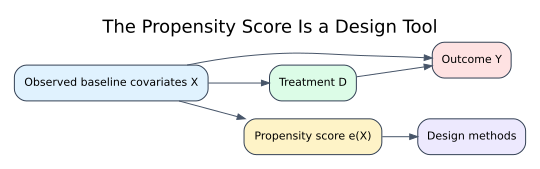

In [3]:
# Define the graph structure for the Why Propensity Scores Exist diagram.
ps_edges = [
    ("Observed baseline covariates X", "Treatment D"),
    ("Observed baseline covariates X", "Outcome Y"),
    ("Treatment D", "Outcome Y"),
    ("Observed baseline covariates X", "Propensity score e(X)"),
    ("Propensity score e(X)", "Design methods"),
]

ps_colors = {
    "Observed baseline covariates X": "#e0f2fe",
    "Treatment D": "#dcfce7",
    "Outcome Y": "#fee2e2",
    "Propensity score e(X)": "#fef3c7",
    "Design methods": "#ede9fe",
}

smart_display(make_dag(ps_edges, "The Propensity Score Is a Design Tool", ps_colors))

The score is built from baseline covariates and treatment assignment. It should not be built from the outcome. In a disciplined workflow, the propensity-score stage tries to create a comparison design before estimating the treatment effect.

That design-stage framing is important. If we repeatedly change the propensity-score model after seeing the outcome result, the analysis becomes easier to overfit to the conclusion we want.

## 2. Identification: What the Score Can and Cannot Do

The propensity score helps with observed confounding. It does not solve unobserved confounding.

The standard assumptions are the same as in regression adjustment:

$$
(Y(1), Y(0)) \perp D \mid X
$$

$$
0 < P(D=1 \mid X=x) < 1
$$

If treatment assignment is conditionally exchangeable given `X`, then it is also conditionally exchangeable given the true propensity score `e(X)`. That is the dimension-reduction result. It does not say that any estimated score is good enough, and it does not say that hidden confounders disappear.

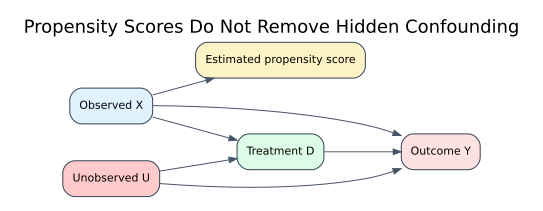

In [4]:
# Organize the calculation into readable steps for the lecture narrative.
unobserved_edges = [
    ("Observed X", "Treatment D"),
    ("Observed X", "Outcome Y"),
    ("Unobserved U", "Treatment D"),
    ("Unobserved U", "Outcome Y"),
    ("Treatment D", "Outcome Y"),
    ("Observed X", "Estimated propensity score"),
]

unobserved_colors = {
    "Observed X": "#e0f2fe",
    "Unobserved U": "#fecaca",
    "Treatment D": "#dcfce7",
    "Outcome Y": "#fee2e2",
    "Estimated propensity score": "#fef3c7",
}

smart_display(make_dag(unobserved_edges, "Propensity Scores Do Not Remove Hidden Confounding", unobserved_colors))

The hidden variable `U` still creates a backdoor path. A propensity score estimated from observed `X` cannot balance something that was not measured.

This is why propensity-score analyses should end with a limitations section and, when possible, a sensitivity analysis. That comes later in this module.

## 3. Running Example: Targeted Customer-Success Outreach

We will continue the same industry setting as the regression-adjustment notebook.

A SaaS company gives proactive customer-success outreach to selected accounts. Selection is not random. Outreach is more likely when an account has high risk, lower usage, certain plan tiers, and when the customer-success team has available capacity.

The business question remains:

> What is the causal effect of proactive outreach on next-quarter account health?

The propensity-score question is different:

> Given pre-outreach information, how likely was each account to receive outreach?

**Dataset and experiment setup.** The dataset represents a targeted outreach program, not a randomized experiment. Each customer has pre-treatment features that affect both outreach probability and renewal outcomes. The propensity score is the probability that a customer receives outreach given these observed features. The simulation is useful because it includes realistic targeting pressure and overlap problems while still preserving a known truth for validation. The key teaching point is that a propensity score models the assignment process; it is not a model of the outcome and it cannot repair unmeasured confounding.

In [5]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_customer_success(n=9000, seed=2027):
    """Generate an observational customer-success outreach dataset with measured confounding.

    Args:
        n: Number of simulated units.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    rng = np.random.default_rng(seed)

    plan = rng.choice(["startup", "growth", "enterprise"], p=[0.42, 0.38, 0.20], size=n)
    plan_effect = pd.Series(plan).map({"startup": 0.0, "growth": 3.0, "enterprise": 7.0}).to_numpy()

    tenure = np.clip(rng.gamma(shape=2.2, scale=7.0, size=n), 1, 48)
    usage = np.clip(rng.normal(50 + 0.6 * tenure + 2.0 * plan_effect, 12, n), 5, 120)
    pre_value = np.clip(rng.normal(80 + 1.2 * tenure + 5.0 * plan_effect, 18, n), 20, 220)
    risk_score = expit(1.4 - 0.045 * usage - 0.012 * pre_value + rng.normal(0, 0.8, n))

    manager_capacity = rng.normal(0, 1, n)

    treatment_probability = expit(
        -2.15
        + 4.1 * risk_score
        + 0.45 * (plan == "enterprise")
        + 0.25 * (plan == "growth")
        - 0.008 * tenure
        + 0.85 * manager_capacity
    )
    treated = rng.binomial(1, treatment_probability)

    y0 = (
        62
        + 0.10 * pre_value
        + 0.18 * tenure
        + 0.22 * usage
        + plan_effect
        - 22 * risk_score
        + 8 * risk_score**2
        + rng.normal(0, 4.5, n)
    )

    individual_effect = (
        3.0
        + 1.00 * (plan == "enterprise")
        + 0.45 * (plan == "growth")
        - 1.40 * risk_score
        + 0.012 * usage
    )

    outcome = y0 + individual_effect * treated

    return pd.DataFrame({
        "plan": plan,
        "tenure": tenure,
        "usage": usage,
        "pre_value": pre_value,
        "risk_score": risk_score,
        "manager_capacity": manager_capacity,
        "true_propensity": treatment_probability,
        "treated": treated,
        "y0": y0,
        "true_individual_effect": individual_effect,
        "outcome": outcome,
    })


df = simulate_customer_success()
true_ate = df["true_individual_effect"].mean()
naive_effect = df.loc[df["treated"] == 1, "outcome"].mean() - df.loc[df["treated"] == 0, "outcome"].mean()

summary = pd.DataFrame({
    "quantity": [
        "Number of accounts",
        "Share receiving outreach",
        "True ATE in simulation",
        "Naive treated-control difference",
        "Bias of naive difference",
    ],
    "value": [
        len(df),
        df["treated"].mean(),
        true_ate,
        naive_effect,
        naive_effect - true_ate,
    ],
})

smart_display(summary)
smart_display(df.head())

,quantity,value
0,Number of accounts,9000.000000
1,Share receiving outreach,0.184333
2,True ATE in simulation,4.022963
3,Naive treated-control difference,2.502667
4,Bias of naive difference,-1.520296


,plan,tenure,usage,pre_value,risk_score,manager_capacity,true_propensity,treated,y0,true_individual_effect,outcome
0,startup,20.223,68.913,110.998,0.061,2.792,0.577,1,85.746,3.742,89.488
1,startup,8.633,56.951,88.643,0.135,-0.646,0.098,0,91.098,3.495,91.098
2,startup,10.115,52.612,106.133,0.075,-0.192,0.110,0,80.257,3.527,80.257
3,growth,3.034,56.377,113.106,0.236,-0.691,0.176,0,84.416,3.796,84.416
4,growth,35.204,62.662,135.905,0.014,0.417,0.145,0,100.915,4.183,100.915


The true ATE is available because this is a simulation. In a real observational study, we would not know it.

The naive treated-control comparison is biased because outreach is targeted. The purpose of the propensity score is to reconstruct a more credible comparison by balancing the observed baseline variables that drove selection into outreach.

## 4. First Look at Imbalance

Before estimating any propensity score, inspect whether treatment groups differ on baseline covariates. If there is no imbalance, the score may add little. If there is severe imbalance, the score will need to work hard, and overlap may be a concern.

,covariate,treated_mean,control_mean,smd,abs_smd
4,manager_capacity,0.617,-0.135,0.785,0.785
0,risk_score,0.116,0.082,0.328,0.328
1,usage,62.162,64.933,-0.190,0.190
3,tenure,14.281,15.599,-0.134,0.134
2,pre_value,110.154,111.612,-0.057,0.057
7,plan_startup,0.395,0.421,-0.054,0.054
5,plan_enterprise,0.219,0.197,0.054,0.054
6,plan_growth,0.386,0.382,0.010,0.010


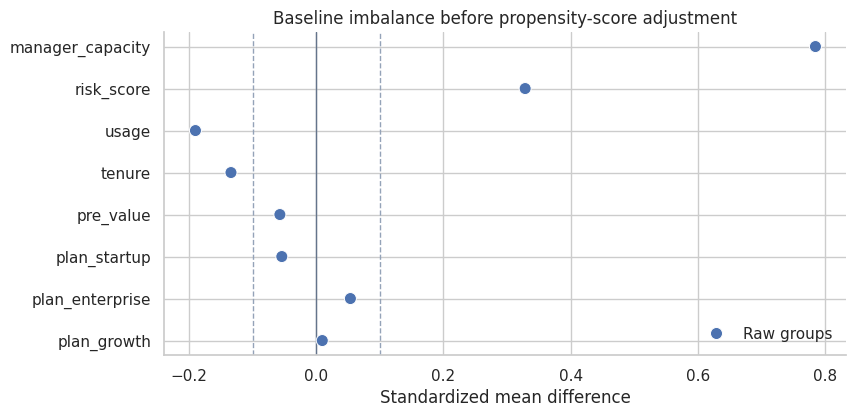

In [6]:
# Prepare the quantities used in the First Look at Imbalance discussion.
plan_dummies = pd.get_dummies(df["plan"], prefix="plan", dtype=float)
balance_frame = pd.concat(
    [df[["treated", "risk_score", "usage", "pre_value", "tenure", "manager_capacity"]], plan_dummies],
    axis=1,
)
balance_covariates = [c for c in balance_frame.columns if c != "treated"]
confounder_covariates = [c for c in balance_covariates if c != "manager_capacity"]

raw_balance = standardized_mean_differences(balance_frame, balance_covariates)
smart_display(raw_balance)

plot_smd_comparison(
    {"Raw groups": raw_balance},
    title="Baseline imbalance before propensity-score adjustment",
)

The raw groups differ strongly. `manager_capacity` is especially imbalanced because it directly affects whether outreach occurs. Some substantive confounders, such as risk and usage, are also imbalanced.

For causal bias, the most important variables are those related to both treatment assignment and the outcome. Variables that predict treatment but do not affect potential outcomes can still matter for design and variance, but they are not confounders in the same sense.

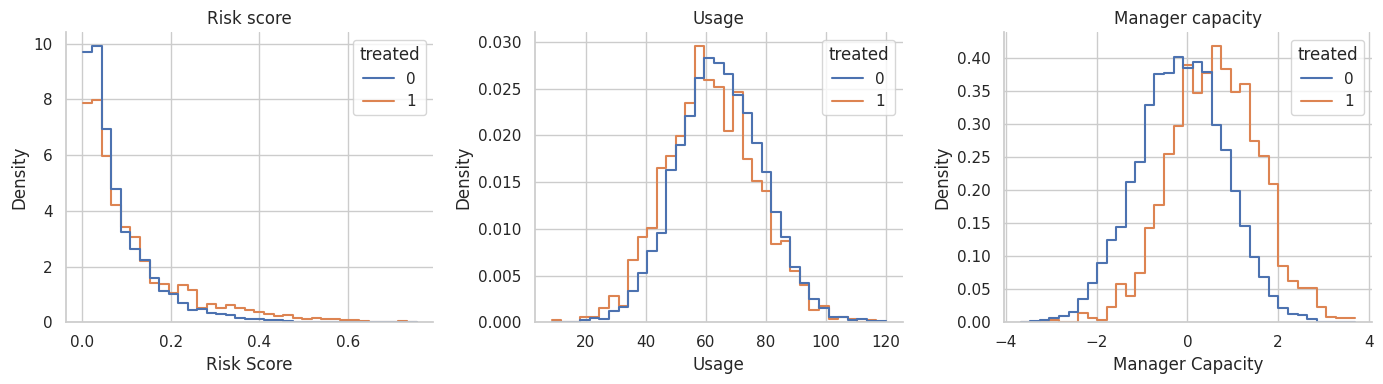

In [7]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in [
    (axes[0], "risk_score", "Risk score"),
    (axes[1], "usage", "Usage"),
    (axes[2], "manager_capacity", "Manager capacity"),
]:
    sns.histplot(
        data=df,
        x=col,
        hue="treated",
        stat="density",
        common_norm=False,
        bins=35,
        element="step",
        fill=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel(col.replace("_", " ").title())
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Risk and usage are real confounding concerns because they influence both outreach decisions and future account health. Manager capacity is different in this simulation: it affects outreach, but not the potential outcomes. It is an operational driver of assignment rather than a customer-health driver.

This distinction becomes important when we ask whether the propensity-score model should maximize treatment prediction or balance the covariates that matter for confounding.

## 5. Estimate Propensity Scores

We will fit three logistic propensity-score models:

1. **Underspecified score**: omits risk and usage, the important confounders.
2. **Confounder score**: includes the customer variables that affect both treatment and outcome.
3. **Kitchen-sink score**: also includes manager capacity, a strong treatment predictor that does not affect potential outcomes in the simulation.

The aim is to see how different score choices affect balance, overlap, and estimator stability.

In [8]:
# Build the summary table used to connect the calculation back to the design question.
ps_models = [
    fit_propensity_logit(
        "treated ~ pre_value + tenure + C(plan)",
        df,
        "Underspecified score",
    ),
    fit_propensity_logit(
        "treated ~ pre_value + tenure + usage + risk_score + I(risk_score ** 2) + C(plan)",
        df,
        "Confounder score",
    ),
    fit_propensity_logit(
        "treated ~ pre_value + tenure + usage + risk_score + I(risk_score ** 2) + C(plan) + manager_capacity",
        df,
        "Kitchen-sink score",
    ),
]

for item in ps_models:
    df[item["label"]] = item["score"]

ps_diagnostics = []
for item in ps_models:
    score = item["score"]
    weights = ate_weights(df["treated"], score)
    ps_diagnostics.append({
        "score_model": item["label"],
        "auc_for_treatment_prediction": roc_auc_score(df["treated"], score),
        "min_score": score.min(),
        "p01_score": np.quantile(score, 0.01),
        "median_score": np.median(score),
        "p99_score": np.quantile(score, 0.99),
        "max_score": score.max(),
        "effective_sample_size_if_weighted": effective_sample_size(weights),
        "weighted_ate_preview": weighted_ate(df["outcome"], df["treated"], score),
    })

ps_diagnostics = pd.DataFrame(ps_diagnostics)
ps_diagnostics["bias_of_weighted_ate_preview"] = ps_diagnostics["weighted_ate_preview"] - true_ate
smart_display(ps_diagnostics)

,score_model,auc_for_treatment_prediction,min_score,p01_score,median_score,p99_score,max_score,effective_sample_size_if_weighted,weighted_ate_preview,bias_of_weighted_ate_preview
0,Underspecified score,0.541373,0.106817,0.124008,0.186513,0.230547,0.244754,5341.190151,2.907778,-1.115185
1,Confounder score,0.596101,0.096960,0.112425,0.171520,0.454942,0.841913,5084.880598,4.024966,0.002003
2,Kitchen-sink score,0.737470,0.010000,0.020750,0.148941,0.654602,0.938635,3314.342819,3.469124,-0.553839


The treatment-prediction AUC rises when the model includes stronger assignment predictors. Causal design quality still depends on balance, overlap, stability, and the target estimand.

The underspecified score predicts treatment weakly and fails to include important confounders. The kitchen-sink score predicts treatment much better, but it also creates more extreme weights and a smaller effective sample size. The confounder score focuses on variables needed to reduce confounding.

The weighted ATE shown here is only a preview. The dedicated weighting notebook will handle inverse probability weighting carefully. For now, notice the main lesson: treatment prediction and causal estimation are related, but not identical goals.

## 6. The Propensity Score Distribution

Propensity scores should be inspected by treatment group. We want treated and untreated units to share common score ranges. If one group lives in a score region where the other group has no observations, we do not have an empirical comparison.

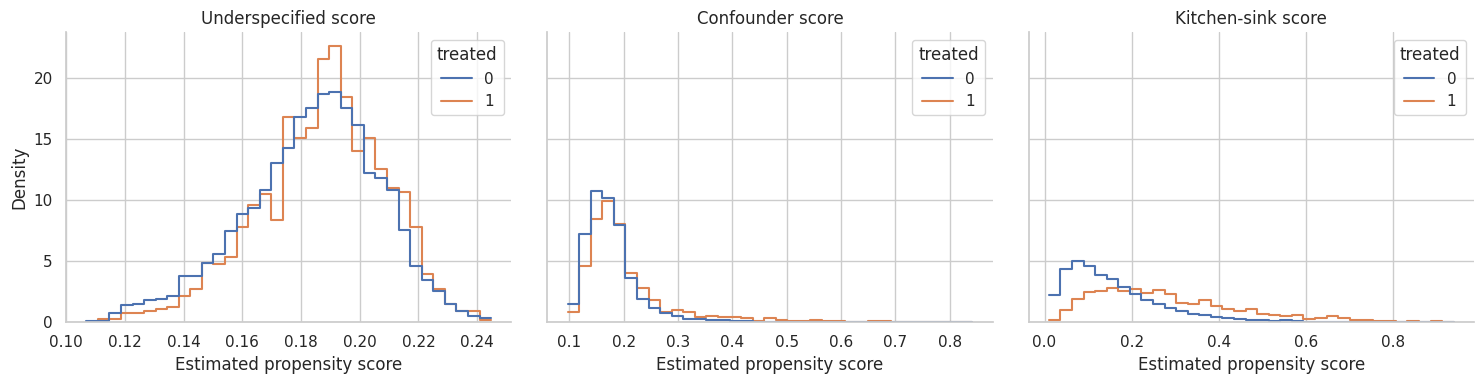

In [9]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, item in zip(axes, ps_models):
    col = item["label"]
    sns.histplot(
        data=df,
        x=col,
        hue="treated",
        stat="density",
        common_norm=False,
        bins=35,
        element="step",
        fill=False,
        ax=ax,
    )
    ax.set_title(col)
    ax.set_xlabel("Estimated propensity score")
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

The underspecified score compresses everyone into a narrow score range. That can make overlap look comfortable even though important confounders are not balanced.

The kitchen-sink score spreads the treatment groups apart because it includes a strong operational driver of assignment. This may improve the assignment model but can make estimation more variable.

The confounder score gives a middle ground: it captures the observed confounding structure without chasing every possible treatment predictor.

In [10]:
# Assemble the Interpretation summary table used for interpretation.
support_tables = []
for item in ps_models:
    table = common_support_table(df, item["label"])
    table.insert(0, "score_model", item["label"])
    support_tables.append(table)

support_table = pd.concat(support_tables, ignore_index=True)
smart_display(support_table)

,score_model,quantity,value
0,Underspecified score,Minimum score among treated,0.112269
1,Underspecified score,Maximum score among treated,0.242230
2,Underspecified score,Minimum score among controls,0.106817
3,Underspecified score,Maximum score among controls,0.244754
4,Underspecified score,Common-support lower bound,0.112269
5,Underspecified score,Common-support upper bound,0.242230
6,Underspecified score,Share of observations inside common support,0.998667
7,Confounder score,Minimum score among treated,0.104751
8,Confounder score,Maximum score among treated,0.841913
9,Confounder score,Minimum score among controls,0.096960


Common support is not just a yes-or-no condition. It is a matter of degree. A score model can technically have overlapping ranges but still have weak practical overlap if one group is sparse in important regions.

In stakeholder language, overlap asks: "For the customers we want to evaluate, do we have comparable customers who did and did not receive the intervention?"

## 7. Balance Is the Main Diagnostic

Austin (2011) emphasizes balance diagnostics for propensity-score methods and discourages using significance tests as the main way to assess balance. The reason is practical: balance is a property of the constructed sample or weighted pseudo-population, not a hypothesis test about a superpopulation.

The standard workhorse is the standardized mean difference.

For a covariate `X`, the raw SMD is:

$$
SMD = \frac{\bar{X}_{treated} - \bar{X}_{control}}{\sqrt{(s^2_{treated} + s^2_{control})/2}}
$$

Values near zero mean the treated and control groups are similar on that covariate.

,design,max_abs_smd_all_variables,mean_abs_smd_all_variables,max_abs_smd_confounders_only,mean_abs_smd_confounders_only
0,Raw groups,0.784591,0.201368,0.328442,0.118050
1,Underspecified score,0.788538,0.157955,0.301069,0.067872
2,Confounder score,0.817372,0.104941,0.005833,0.003165
3,Kitchen-sink score,0.040286,0.017694,0.040286,0.019828


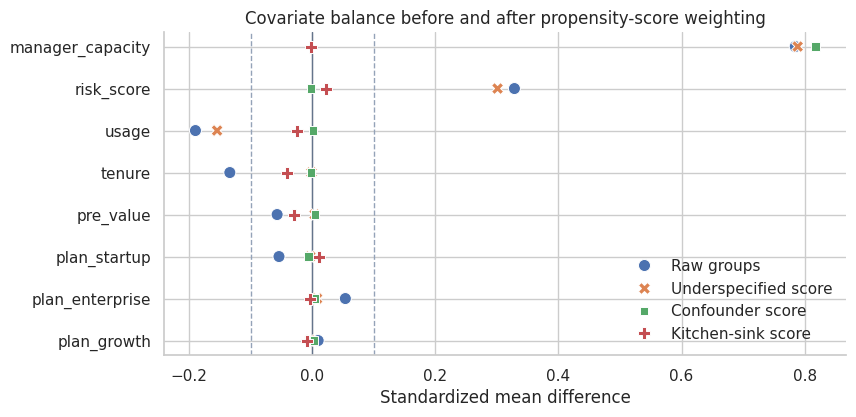

In [11]:
# Build the summary table used to connect the calculation back to the design question.
balance_tables_all = {"Raw groups": raw_balance}
balance_tables_confounders = {"Raw groups": raw_balance.query("covariate != 'manager_capacity'")}

for item in ps_models:
    weights = ate_weights(df["treated"], item["score"])
    weighted_balance = standardized_mean_differences(balance_frame, balance_covariates, weights=weights)
    balance_tables_all[item["label"]] = weighted_balance
    balance_tables_confounders[item["label"]] = weighted_balance.query("covariate != 'manager_capacity'")

balance_summary = []
for label, table in balance_tables_all.items():
    balance_summary.append({
        "design": label,
        "max_abs_smd_all_variables": table["abs_smd"].max(),
        "mean_abs_smd_all_variables": table["abs_smd"].mean(),
        "max_abs_smd_confounders_only": table.query("covariate != 'manager_capacity'")["abs_smd"].max(),
        "mean_abs_smd_confounders_only": table.query("covariate != 'manager_capacity'")["abs_smd"].mean(),
    })

balance_summary = pd.DataFrame(balance_summary)
smart_display(balance_summary)

plot_smd_comparison(
    {
        "Raw groups": balance_tables_all["Raw groups"],
        "Underspecified score": balance_tables_all["Underspecified score"],
        "Confounder score": balance_tables_all["Confounder score"],
        "Kitchen-sink score": balance_tables_all["Kitchen-sink score"],
    },
    title="Covariate balance before and after propensity-score weighting",
)

The underspecified score leaves important imbalance because it omitted the variables that created confounding. The confounder score balances the customer-health covariates very well. The kitchen-sink score balances almost everything, including manager capacity, but it came with a lower effective sample size.

This is the balancing-score idea in action. A useful propensity score is not merely one that predicts treatment. It is one that creates comparable treated and untreated groups on the observed pre-treatment covariates needed for the causal question.

## 8. AUC Is Not the Target

It is tempting to treat propensity-score modeling like a classification problem. But the objective is different.

A high-AUC treatment model answers:

> Can we distinguish treated from untreated units?

A good causal design asks:

> After using the score, are treated and untreated units comparable on baseline confounders, with enough overlap to estimate the target effect?

Sometimes these goals align. Sometimes they do not.

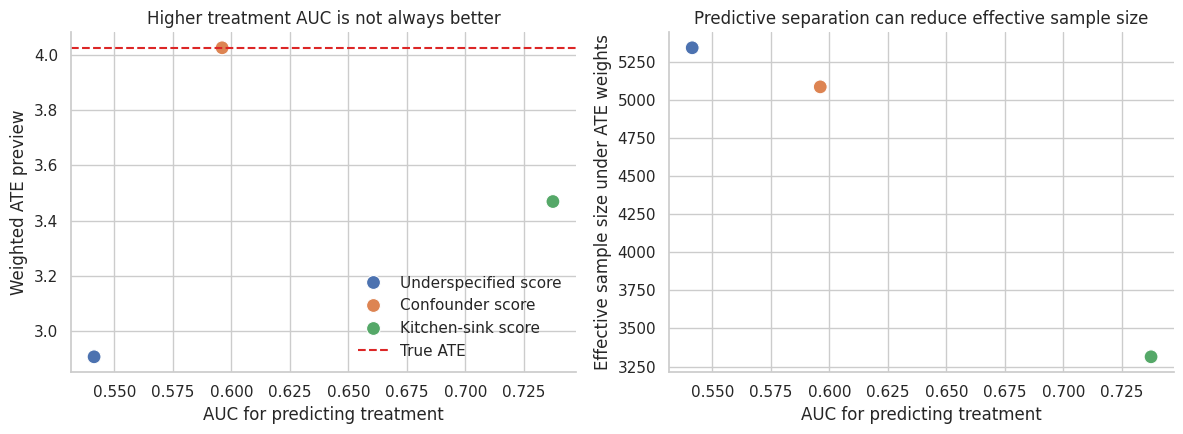

In [12]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.scatterplot(
    data=ps_diagnostics,
    x="auc_for_treatment_prediction",
    y="weighted_ate_preview",
    hue="score_model",
    s=100,
    ax=axes[0],
)
axes[0].axhline(true_ate, color="#dc2626", linestyle="--", linewidth=1.5, label="True ATE")
axes[0].set_title("Higher treatment AUC is not always better")
axes[0].set_xlabel("AUC for predicting treatment")
axes[0].set_ylabel("Weighted ATE preview")
axes[0].legend(frameon=False)

sns.scatterplot(
    data=ps_diagnostics,
    x="auc_for_treatment_prediction",
    y="effective_sample_size_if_weighted",
    hue="score_model",
    s=100,
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Predictive separation can reduce effective sample size")
axes[1].set_xlabel("AUC for predicting treatment")
axes[1].set_ylabel("Effective sample size under ATE weights")

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

The kitchen-sink score has the highest AUC because it includes a strong operational predictor of treatment. But its weighted ATE preview is not the closest in this finite sample, and its effective sample size is smaller.

Operational variables can be useful, and the score model should be judged by the causal design it creates: balance, overlap, stability, and alignment with the estimand.

## 9. Propensity-Score Subclassification

One simple use of propensity scores is subclassification. Split units into strata based on the estimated propensity score, compare treated and untreated outcomes within each stratum, then average the stratum-level contrasts.

This approximates conditioning on the score:

$$
E[Y(1) - Y(0)] \approx \sum_s P(S=s) \left(E[Y \mid D=1, S=s] - E[Y \mid D=0, S=s]\right)
$$

where `S` is a propensity-score stratum.

In [13]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def subclassification_estimate(frame, score_col, n_strata):
    """
    Estimate an ATE by comparing treated and comparison units inside propensity-score strata.
    
    Idea:
        Subclassification approximates adjustment by making comparisons within groups that have similar estimated treatment probabilities.
    
    Args:
        frame: Analysis DataFrame containing the treatment, outcome, score, or covariate columns used by the helper.
        score_col: Column containing the estimated propensity score used to form strata.
        n_strata: Number of propensity-score strata used in subclassification.
    
    Returns:
        pandas.DataFrame: Stratum-level effects, counts, weights, and contribution to the overall estimate.
    """
    work = frame.copy()
    work["stratum"] = pd.qcut(work[score_col], q=n_strata, labels=False, duplicates="drop") + 1
    rows = []
    for stratum, group in work.groupby("stratum", observed=True):
        if group["treated"].nunique() < 2:
            continue
        treated_group = group[group["treated"] == 1]
        control_group = group[group["treated"] == 0]
        diff = treated_group["outcome"].mean() - control_group["outcome"].mean()
        rows.append({
            "stratum": int(stratum),
            "accounts": len(group),
            "treated_accounts": len(treated_group),
            "control_accounts": len(control_group),
            "mean_score": group[score_col].mean(),
            "outreach_rate": group["treated"].mean(),
            "within_stratum_difference": diff,
            "true_stratum_ate": group["true_individual_effect"].mean(),
        })
    table = pd.DataFrame(rows)
    estimate = np.average(table["within_stratum_difference"], weights=table["accounts"])
    return table, estimate

subclass_rows = []
subclass_tables = {}
for n_strata in [5, 10, 20]:
    table, estimate = subclassification_estimate(df, "Confounder score", n_strata=n_strata)
    subclass_tables[n_strata] = table
    subclass_rows.append({
        "number_of_strata": n_strata,
        "subclassification_estimate": estimate,
        "bias_vs_true_ate": estimate - true_ate,
    })

subclass_summary = pd.DataFrame(subclass_rows)
smart_display(subclass_summary)
smart_display(subclass_tables[5])

,number_of_strata,subclassification_estimate,bias_vs_true_ate
0,5,3.533,-0.490
1,10,3.777,-0.246
2,20,3.931,-0.092


,stratum,accounts,treated_accounts,control_accounts,mean_score,outreach_rate,within_stratum_difference,true_stratum_ate
0,1,1800,222,1578,0.129,0.123,3.936,3.859
1,2,1800,281,1519,0.152,0.156,4.047,4.031
2,3,1800,324,1476,0.171,0.180,4.663,4.178
3,4,1800,346,1454,0.193,0.192,3.735,4.294
4,5,1800,486,1314,0.276,0.270,1.282,3.753


Coarse subclassification improves on the naive comparison but may still leave residual imbalance within strata. More strata can approximate conditioning on the score more closely, but only if each stratum still contains enough treated and control units.

This is the same tradeoff that appears throughout observational causal inference: finer adjustment reduces bias only when the data can support the comparison.

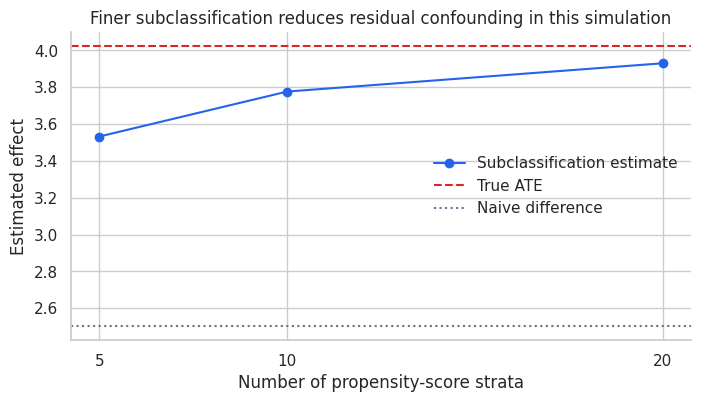

In [14]:
# Build the Interpretation plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = subclass_summary.copy()
ax.plot(plot_df["number_of_strata"], plot_df["subclassification_estimate"], marker="o", color="#2563eb", label="Subclassification estimate")
ax.axhline(true_ate, color="#dc2626", linestyle="--", linewidth=1.5, label="True ATE")
ax.axhline(naive_effect, color="#64748b", linestyle=":", linewidth=1.5, label="Naive difference")
ax.set_xticks(plot_df["number_of_strata"])
ax.set_xlabel("Number of propensity-score strata")
ax.set_ylabel("Estimated effect")
ax.set_title("Finer subclassification reduces residual confounding in this simulation")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.show()

The estimate moves toward the true ATE as the score is stratified more finely. This is not guaranteed in every dataset. If strata become too small or overlap is weak, estimates can become noisy or unstable.

The next two notebooks will look more directly at matching and inverse probability weighting. Subclassification is a helpful bridge because it makes the balancing logic visible.

## 10. Propensity Score Covariate Adjustment

Another simple use is to include the propensity score itself as a covariate in an outcome regression:

$$
E[Y \mid D, e(X)] = \alpha + \tau D + f(e(X))
$$

This is not a universal fix. It can work in simple settings, but it compresses all covariate information into a score and then relies on the chosen functional form for the score-outcome relationship.

,model,estimate,ci_low,ci_high,bias_vs_true_ate
0,Naive regression,2.502667,1.948475,3.056860,-1.520296
1,Linear PS adjustment,3.986883,3.486243,4.487523,-0.036080
2,Flexible PS adjustment,4.012644,3.513959,4.511329,-0.010319
3,Full covariate outcome adjustment,3.989928,3.749290,4.230566,-0.033035


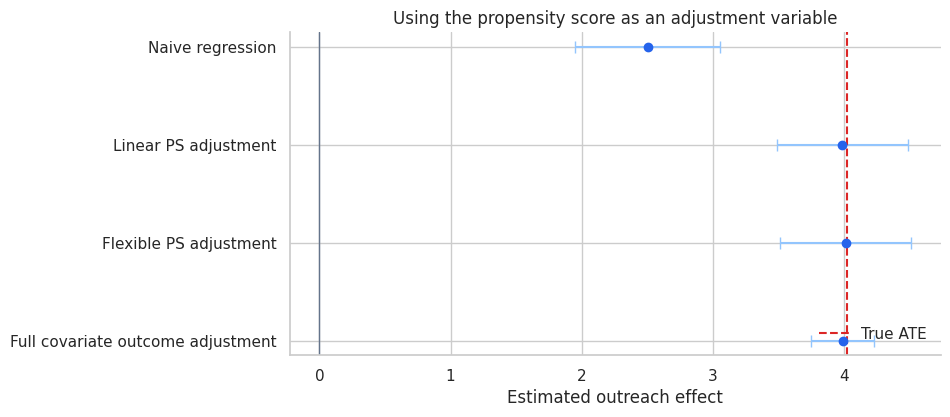

In [15]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
ps_adjustment_models = {
    "Naive regression": smf.ols("outcome ~ treated", data=df).fit(cov_type="HC3"),
    "Linear PS adjustment": smf.ols("outcome ~ treated + Q('Confounder score')", data=df).fit(cov_type="HC3"),
    "Flexible PS adjustment": smf.ols(
        "outcome ~ treated + Q('Confounder score') + I(Q('Confounder score') ** 2) + I(Q('Confounder score') ** 3)",
        data=df,
    ).fit(cov_type="HC3"),
    "Full covariate outcome adjustment": smf.ols(
        "outcome ~ treated + pre_value + tenure + usage + risk_score + I(risk_score ** 2) + C(plan)",
        data=df,
    ).fit(cov_type="HC3"),
}

rows = []
for label, model in ps_adjustment_models.items():
    ci = model.conf_int().loc["treated"]
    rows.append({
        "model": label,
        "estimate": model.params["treated"],
        "ci_low": ci.iloc[0],
        "ci_high": ci.iloc[1],
        "bias_vs_true_ate": model.params["treated"] - true_ate,
    })
ps_adjustment_table = pd.DataFrame(rows)
smart_display(ps_adjustment_table)

fig, ax = plt.subplots(figsize=(8.4, 4.2))
plot_df = ps_adjustment_table.iloc[::-1].reset_index(drop=True)
y = np.arange(len(plot_df))
x = plot_df["estimate"]
ax.errorbar(
    x,
    y,
    xerr=[x - plot_df["ci_low"], plot_df["ci_high"] - x],
    fmt="o",
    color="#2563eb",
    ecolor="#93c5fd",
    capsize=4,
)
ax.axvline(true_ate, color="#dc2626", linestyle="--", linewidth=1.5, label="True ATE")
ax.axvline(0, color="#64748b", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(plot_df["model"])
ax.set_xlabel("Estimated outreach effect")
ax.set_title("Using the propensity score as an adjustment variable")
ax.legend(frameon=False, loc="lower right")
sns.despine(ax=ax)
plt.show()

Adjusting for the estimated propensity score can reduce bias relative to the naive model, but it is sensitive to functional form. A flexible score adjustment does better than a linear-only score adjustment in this simulation.

This is why many applied workflows use the propensity score primarily to create a design: matching, subclassification, weighting, or overlap restriction. Outcome modeling can still be used afterward, but the design diagnostics come first.

## 11. What Variables Should Go Into the Score?

A practical propensity-score model should be based on pre-treatment information. Candidate variables usually include:

- Known causes of treatment assignment and outcome.
- Strong predictors of the outcome, even if their relationship to treatment is modest.
- Variables used in eligibility rules, targeting policies, or operational assignment.
- Segment indicators needed for the target comparison.

Be careful with:

- Post-treatment variables.
- Outcomes or proxies measured after treatment.
- Variables affected by treatment.
- Pure treatment predictors that create extreme scores without improving confounder balance.

Caliendo and Kopeinig (2008) discuss practical implementation choices for propensity-score matching. Stuart (2010) frames matching methods as attempts to replicate key features of randomized experiments by creating treated and control groups with similar covariate distributions.

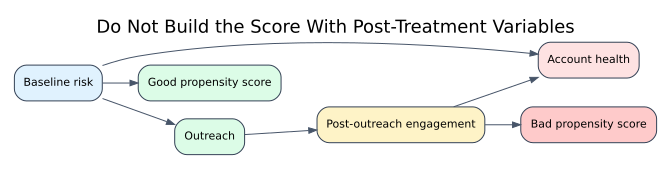

In [16]:
# Organize the calculation into readable steps for the lecture narrative.
bad_ps_edges = [
    ("Baseline risk", "Outreach"),
    ("Baseline risk", "Account health"),
    ("Outreach", "Post-outreach engagement"),
    ("Post-outreach engagement", "Account health"),
    ("Post-outreach engagement", "Bad propensity score"),
    ("Baseline risk", "Good propensity score"),
]

bad_ps_colors = {
    "Baseline risk": "#e0f2fe",
    "Outreach": "#dcfce7",
    "Post-outreach engagement": "#fef3c7",
    "Account health": "#fee2e2",
    "Bad propensity score": "#fecaca",
    "Good propensity score": "#dcfce7",
}

smart_display(make_dag(bad_ps_edges, "Do Not Build the Score With Post-Treatment Variables", bad_ps_colors))

A propensity score should model treatment assignment using information available before treatment. If the score includes post-treatment engagement, it is no longer modeling the treatment assignment process. It is conditioning on a consequence of treatment.

This can change the estimand, block part of the causal effect, or introduce new bias. Timing is not a documentation detail. It is part of the identification strategy.

## 12. A Propensity-Score Workflow

A professional propensity-score analysis usually follows this order:

| Step | Question | Output |
|---|---|---|
| 1. Estimand | What treatment effect and target population? | ATE, ATT, overlap population, or segment effect. |
| 2. Assignment story | Why did units receive treatment? | Business rule, model trigger, team process, eligibility logic. |
| 3. Candidate covariates | What pre-treatment variables drive treatment and outcome? | DAG, timing table, feature list. |
| 4. Score model | What predicts treatment before outcome is used? | Logistic or ML score model. |
| 5. Overlap | Do treated and untreated units share score ranges? | Score distributions, common-support table. |
| 6. Balance | Did the score balance observed covariates? | SMD table and plot before/after design. |
| 7. Estimator | How will the score be used? | Matching, subclassification, weighting, or adjustment. |
| 8. Outcome analysis | What is the effect estimate and uncertainty? | Effect table plus robustness checks. |
| 9. Threats | What remains unaddressed? | Unmeasured confounding, measurement error, interference. |

This workflow helps keep the score in its proper role. The propensity score is part of the design, not a magic variable that makes an observational study causal by itself.

## 13. Practical Checklist

Before trusting a propensity-score analysis, ask:

- Were all score variables measured before treatment?
- Are the variables justified by the assignment process and causal graph?
- Does the score have enough overlap between treated and control units?
- Did balance improve on the important confounders?
- Are any weights extreme or is the effective sample size too small?
- Is the chosen estimand clear: ATE, ATT, or overlap population?
- Are results robust to reasonable score specifications?
- Is unmeasured confounding still plausible?

If the answer to the balance or overlap questions is weak, do not rush to the outcome estimate. Fix the design or narrow the estimand first.

## Key Takeaways

- The propensity score is the probability of treatment assignment conditional on observed baseline covariates.
- Its value comes from balance: treated and control groups with the same true score have the same distribution of observed covariates.
- Propensity-score modeling should be treated as a design-stage activity.
- Treatment-prediction AUC is not the main diagnostic. Balance and overlap are more important for causal work.
- A score that omits important confounders can look stable but remain biased.
- A score that chases every treatment predictor can create extreme weights and weak practical overlap.
- Propensity scores support several estimators: matching, subclassification, weighting, and covariate adjustment.
- They do not solve unmeasured confounding.

## 13. Real-Data Companion: Propensity Scores in Bank Marketing Data

The next few observational-adjustment lectures use carefully controlled simulations because that is the only way to know the true causal effect. The UCI Bank Marketing data add a different kind of realism. The data contain real customer attributes, real campaign-contact histories, and a real subscription outcome.

The companion treats multiple campaign contacts as an exposure and term-deposit subscription as the outcome. That exposure was not randomly assigned, and some variables in the dataset are measured during the campaign. The section is therefore a design realism check, not a claim that repeated contacts caused subscription. The value is that the messiness looks like real customer-contact data: targeting, imbalance, sparse histories, categorical covariates, and limited overlap.

Data source: [UCI Bank Marketing dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing).

**How to read this real-data section.** Treat this as design practice rather than a standalone causal claim. The data give us real covariates, messy measurement, and diagnostics to inspect; identification still has to come from assignment rules, timing, exposure definitions, comparison groups, and assumptions.


**Real-data dataset note.** In the bank-marketing companion, the propensity score is a model of observed campaign exposure in a real operational dataset. The units are bank clients, and the measured covariates include demographic, financial, and campaign-history variables. Because assignment was not randomized, the propensity score should be read as a design diagnostic rather than proof of identification. The exercise is useful because real scores often reveal limited overlap, concentrated targeting, and variable types that are less tidy than synthetic examples. That is exactly where propensity-score diagnostics earn their place.

,campaign_contact_group,count,mean,std,min,median,max
0,One contact,17544,0.602,0.065,0.378,0.614,0.749
1,Multiple contacts,27667,0.619,0.061,0.373,0.632,0.744


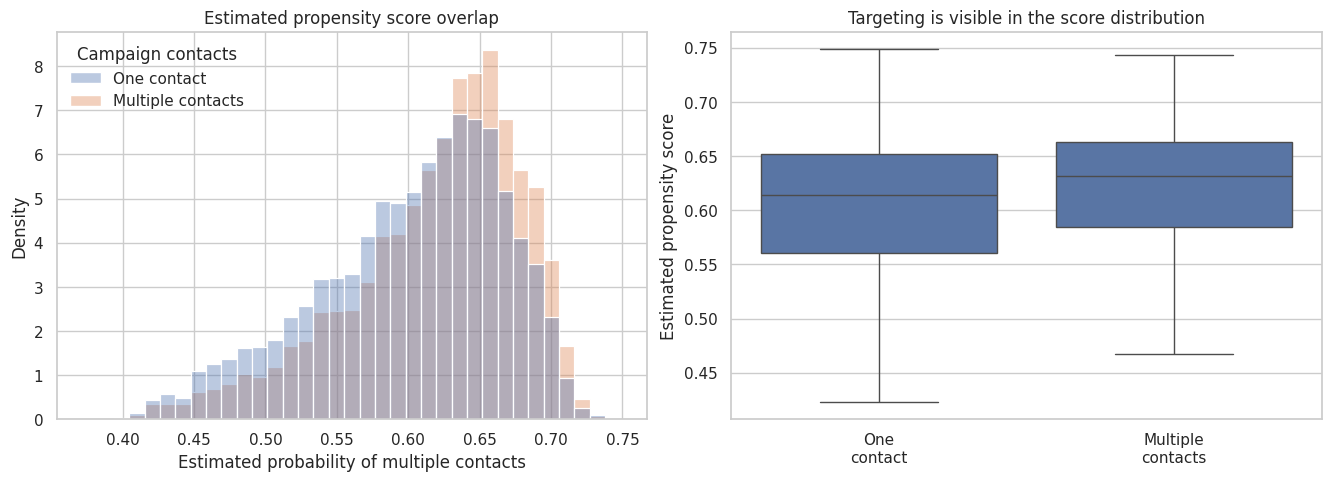

,diagnostic,one_contact,multiple_contacts
0,Share with propensity below 0.05,0.000000,0.000000
1,Share with propensity above 0.80,0.000000,0.000000


In [17]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.real_data import load_uci_bank_marketing, optional_data_note

RUN_REAL_DATA_COMPANION = True
BANK_MARKETING_SOURCE = "https://archive.ics.uci.edu/dataset/222/bank+marketing"

if RUN_REAL_DATA_COMPANION:
    bank = load_uci_bank_marketing().copy()
    bank["subscribed"] = (bank["y"] == "yes").astype(int)
    bank["multiple_contacts"] = (bank["campaign"] > 1).astype(int)
    bank["contact_group"] = bank["multiple_contacts"].map({0: "One contact", 1: "Multiple contacts"})
    bank["has_previous_contact"] = (bank["previous"] > 0).astype(int)
    bank["pdays_observed"] = (bank["pdays"] >= 0).astype(int)
    bank["log_balance"] = np.sign(bank["balance"]) * np.log1p(np.abs(bank["balance"]))
    bank["contact_count_capped"] = bank["campaign"].clip(upper=8)
    baseline_covariates = ["age", "log_balance", "has_previous_contact", "pdays_observed"]

    from sklearn.compose import ColumnTransformer
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

    numeric_features = ["age", "log_balance", "has_previous_contact", "pdays_observed"]
    categorical_features = ["job", "marital", "education", "housing", "loan"]
    model_features = numeric_features + categorical_features

    propensity_pipeline = make_pipeline(
        ColumnTransformer(
            [
                ("numeric", StandardScaler(), numeric_features),
                ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ]
        ),
        LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs"),
    )
    propensity_pipeline.fit(bank[model_features], bank["multiple_contacts"])
    bank["propensity_multiple_contacts"] = propensity_pipeline.predict_proba(bank[model_features])[:, 1].clip(0.001, 0.999)

    ps_summary = (
        bank.groupby("multiple_contacts")["propensity_multiple_contacts"]
        .agg(["count", "mean", "std", "min", "median", "max"])
        .rename(index={0: "One contact", 1: "Multiple contacts"})
        .reset_index(names="campaign_contact_group")
    )
    smart_display(ps_summary.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.7), constrained_layout=True)
    contact_order = ["One contact", "Multiple contacts"]
    sns.histplot(
        data=bank,
        x="propensity_multiple_contacts",
        hue="contact_group",
        hue_order=contact_order,
        stat="density",
        common_norm=False,
        bins=35,
        alpha=0.38,
        ax=axes[0],
    )
    axes[0].set_title("Estimated propensity score overlap")
    axes[0].set_xlabel("Estimated probability of multiple contacts")
    axes[0].set_ylabel("Density")
    legend = axes[0].get_legend()
    if legend is not None:
        legend.set_title("Campaign contacts")
        legend.set_frame_on(False)

    sns.boxplot(
        data=bank,
        x="contact_group",
        y="propensity_multiple_contacts",
        order=contact_order,
        showfliers=False,
        ax=axes[1],
    )
    axes[1].set_xticklabels(["One\ncontact", "Multiple\ncontacts"])
    axes[1].set_title("Targeting is visible in the score distribution")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Estimated propensity score")
    plt.show()

    overlap_table = pd.DataFrame(
        [
            {
                "diagnostic": "Share with propensity below 0.05",
                "one_contact": np.mean(bank.loc[bank["multiple_contacts"] == 0, "propensity_multiple_contacts"] < 0.05),
                "multiple_contacts": np.mean(bank.loc[bank["multiple_contacts"] == 1, "propensity_multiple_contacts"] < 0.05),
            },
            {
                "diagnostic": "Share with propensity above 0.80",
                "one_contact": np.mean(bank.loc[bank["multiple_contacts"] == 0, "propensity_multiple_contacts"] > 0.80),
                "multiple_contacts": np.mean(bank.loc[bank["multiple_contacts"] == 1, "propensity_multiple_contacts"] > 0.80),
            },
        ]
    )
    smart_display(overlap_table.round(3))
else:
    optional_data_note("UCI Bank Marketing", BANK_MARKETING_SOURCE, "RUN_REAL_DATA_COMPANION")

The real propensity-score plot usually looks less tidy than the simulated one. That messiness is useful. The score is both a nuisance model and a design diagnostic; if one exposure group lives mostly in a different part of the score distribution, the causal comparison is leaning heavily on modeling choices rather than direct empirical support.

## References

Austin, P. C. (2011). An introduction to propensity score methods for reducing the effects of confounding in observational studies. *Multivariate Behavioral Research, 46*(3), 399-424. https://doi.org/10.1080/00273171.2011.568786

Caliendo, M., & Kopeinig, S. (2008). Some practical guidance for the implementation of propensity score matching. *Journal of Economic Surveys, 22*(1), 31-72. https://doi.org/10.1111/j.1467-6419.2007.00527.x

Imbens, G. W. (2004). Nonparametric estimation of average treatment effects under exogeneity: A review. *The Review of Economics and Statistics, 86*(1), 4-29. https://doi.org/10.1162/003465304323023651

Rosenbaum, P. R., & Rubin, D. B. (1983). The central role of the propensity score in observational studies for causal effects. *Biometrika, 70*(1), 41-55. https://doi.org/10.1093/biomet/70.1.41

Stuart, E. A. (2010). Matching methods for causal inference: A review and a look forward. *Statistical Science, 25*(1), 1-21. https://doi.org/10.1214/09-STS313